# Kappa hist

In [1]:
import os
# set relative paths to working directory and data
dir_path = os.getcwd()
path2processed = dir_path
print(dir_path)

os.listdir(dir_path)


/Users/sibirrer/Science/Projects/TDCOSMO/7LensMilestone/Likelihoods/MilestoneLikelihood/TDCOSMO_sample/TDCOSMO_data/WGD2038-4008


['.DS_Store',
 'plotkappa_handpickedpaper2038.py',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_45_gal_45_oneoverr_22.5_med_increments2_2_emptymsk.cat',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_45_gal_45_zoverr_22.5_med_increments2_2_emptymsk.cat',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_45_gal_45_zoverr_22.5_med_increments2_2_2_2_emptymsk.cat',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_22.5_med_increments2_2_emptymsk.cat',
 'desj2038_pl_nokext_nokin_dt_weight.csv',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_45_gal_45_oneoverr_22.5_med_increments2_2_2_2_emptymsk.cat',
 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_22.5_med_increments2_emptymsk.cat',
 'kappa_hist_plots_2038.i

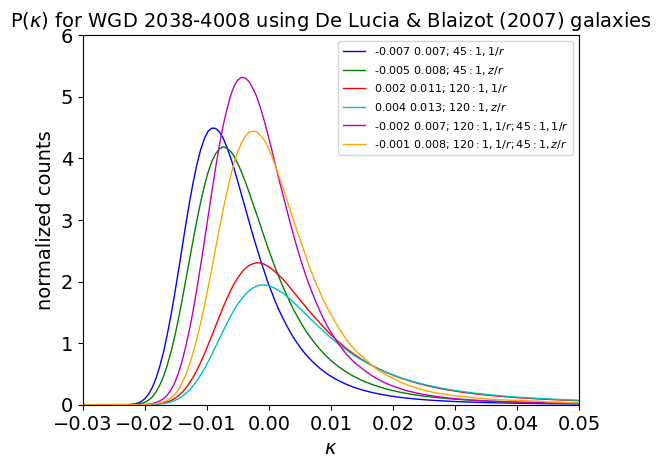

In [2]:
# Plots the equivalent of Figure 13 in Rusu et al. 2017

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
import scipy as sp
from scipy.stats import norm
import numpy as np

min_kappa = -0.20
max_kappa = 1
min_kappa_plot = -0.03
max_kappa_plot = 0.05
bin_stat = 2000
halfwidth = (max_kappa - min_kappa) / (bin_stat * 2.0)

#root = "/Users/cerusu/Dropbox/"
#root = "/Volumes/LaCieSubaru/kapparesults/"
root = dir_path+'/'

def statistics(kappa_all_,bin_stat_,min_kappa_,max_kappa_):
    a, kappa_values = np.histogram([0], bins = bin_stat_, range=(min_kappa_,max_kappa_)) # create an empty histogram of the correct shape

    sum = np.sum(kappa_all_)
    #meanX = np.sum(kappa_counts * (kappa_values[:-1] + halfwidth)) / sum
    #meanX2 = np.sum(kappa_counts * (kappa_values[:-1] + halfwidth) ** 2) / sum
    #std = np.sqrt(meanX2 - meanX**2)

    med = 0
    i = 0
    ok = False
    while (med <= sum/2.0) and (ok == False):
        med = med + kappa_all_[i]
        if med > sum/2.0:
            median = kappa_values[i] + halfwidth
            ok = True
        if med == sum/2.0:
            median = kappa_values[i] + 2 * halfwidth
            ok = True
        i = i + 1

    std = 0
    ok = False
    i = 0
    while (std <= sum * 0.16) and (ok == False):
        std = std + kappa_all_[i]
        if std > sum * 0.16:
            std1_ = kappa_values[i] + halfwidth
            ok = True
        if med == sum*0.16:
            std1_ = kappa_values[i] + 2 * halfwidth
            ok = True
        i = i + 1

    std = 0
    ok = False
    i = 0
    while (std <= sum*0.84) and (ok == False):
        std = std + kappa_all_[i]
        if std > sum*0.84:
            std1 = kappa_values[i] + halfwidth
            ok = True
        if med == sum*0.84:
            std1 = kappa_values[i] + 2 * halfwidth
            ok = True
        i = i + 1

    stddev = (std1 - std1_) / 2

    return median,stddev,kappa_values

def smooth(x,window_len=11,window='hanning'):
    """smooth the data using a window with requested size.

        This method is based on the convolution of a scaled window with the signal.
        The signal is prepared by introducing reflected copies of the signal
        (with the window size) in both ends so that transient parts are minimized
        in the begining and end part of the output signal.

        input:
        x: the input signal
        window_len: the dimension of the smoothing window; should be an odd integer
        window: the type of window from 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'
        flat window will produce a moving average smoothing.

        output: the smoothed signal

        see also:

        numpy.hanning, numpy.hamming, numpy.bartlett, numpy.blackman, numpy.convolve
        scipy.signal.lfilter

        TODO: the window parameter could be the window itself if an array instead of a string
        NOTE: length(output) != length(input), to correct this: return y[(window_len/2-1):-(window_len/2)] instead of just y.
        """

    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")
    if not window in ['flat', 'hanning', 'hamming', 'bartlett', 'blackman']:
        raise ValueError("Window is on of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")
    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")

    if window_len<3:
        return x
    s=np.r_[x[window_len-1:0:-1],x,x[-2:-window_len-1:-1]]
    if window == 'flat': #moving average
        w=np.ones(window_len,'d')
    else:
        w=eval('np.'+window+'(window_len)')
    y=np.convolve(w/w.sum(),s,mode='valid')
    return y

plt.clf()

#kappa_0  = np.loadtxt("%skappahistallLOS_plane44.cat" % root, usecols=[0], unpack=True)
#median0,stddev0,kappa_values = statistics(kappa_0,bin_stat,min_kappa,max_kappa)
#kappa_0 = kappa_0 / np.sum(kappa_0 * np.abs((kappa_values[:-1]+halfwidth)))


kappa_11  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_45_gal_45_oneoverr_22.5_med_increments2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median11,stddev11,kappa_values = statistics(kappa_11,bin_stat,min_kappa,max_kappa)
kappa_11 = kappa_11 / np.sum(kappa_11 * np.abs((kappa_values[:-1]+halfwidth)))

kappa_12  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_45_gal_45_zoverr_22.5_med_increments2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median12,stddev12,kappa_values = statistics(kappa_12,bin_stat,min_kappa,max_kappa)
kappa_12 = kappa_12 / np.sum(kappa_12 * np.abs((kappa_values[:-1]+halfwidth)))

kappa_17  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_22.5_med_increments2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median17,stddev17,kappa_values = statistics(kappa_17,bin_stat,min_kappa,max_kappa)
kappa_17 = kappa_17 / np.sum(kappa_17 * np.abs((kappa_values[:-1]+halfwidth)))

kappa_18  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_45_gal_45_oneoverr_22.5_med_increments2_2_2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median18,stddev18,kappa_values = statistics(kappa_18,bin_stat,min_kappa,max_kappa)
kappa_18 = kappa_18 / np.sum(kappa_18 * np.abs((kappa_values[:-1]+halfwidth)))

kappa_19  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_45_gal_45_zoverr_22.5_med_increments2_2_2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median19,stddev19,kappa_values = statistics(kappa_19,bin_stat,min_kappa,max_kappa)
kappa_19 = kappa_19 / np.sum(kappa_19 * np.abs((kappa_values[:-1]+halfwidth)))

kappa_20  = np.loadtxt("%skappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_zoverr_22.5_med_increments2_2_emptymsk.cat" % root, usecols=[0], unpack=True)
median20,stddev20,kappa_values = statistics(kappa_20,bin_stat,min_kappa,max_kappa)
kappa_20 = kappa_20 / np.sum(kappa_20 * np.abs((kappa_values[:-1]+halfwidth)))

#s = "%.3f %.3f LOS=%d" % (median,std1,LOS)
#s0 = "%.3f %.3f" % (median0,stddev0)
#s1 = "%.3f %.3f" % (median1,stddev1)
#s2 = "%.3f %.3f" % (median2,stddev2)
#s3 = "%.3f %.3f" % (median3,stddev3)
#s4 = "%.3f %.3f" % (median4,stddev4)
#s5 = "%.3f %.3f" % (median5,stddev5)
#s6 = "%.3f %.3f" % (median6,stddev6)
#s7 = "%.3f %.3f" % (median7,stddev7)
#s8 = "%.3f %.3f" % (median8,stddev8)
#s9 = "%.3f %.3f" % (median9,stddev9)
#s10 = "%.3f %.3f" % (median10,stddev10)
s11 = "%.3f %.3f" % (median11,stddev11)
s12 = "%.3f %.3f" % (median12,stddev12)
#s13 = "%.3f %.3f" % (median13,stddev13)
#s14 = "%.3f %.3f" % (median14,stddev14)
#s15 = "%.3f %.3f" % (median15,stddev15)
#s16 = "%.3f %.3f" % (median16,stddev16)
s17 = "%.3f %.3f" % (median17,stddev17)
s18 = "%.3f %.3f" % (median18,stddev18)
s19 = "%.3f %.3f" % (median19,stddev19)
s20 = "%.3f %.3f" % (median20,stddev20)

plt.subplot(1,1,1)
ax = plt.subplot(1,1,1)
ax.tick_params(labelsize=14)
plt.xlim(min_kappa_plot, max_kappa_plot)
plt.ylim(0, 6)

winlen = 12
#smooth(kappa_3,winlen,'flat')
#smooth(kappa_3,winlen,'hanning')
#smooth(kappa_3,winlen,'hamming')
#smooth(kappa_3,winlen,'bartlett')
#smooth(kappa_3,winlen,'blackman')

#plt.plot(kappa_values[:-1],smooth(kappa_0,winlen,'flat')[(winlen/2-1):-(winlen/2)],color='k', linewidth=1, linestyle='-', label ='%s; all LOS' %s0)


plt.plot(kappa_values[:-1],smooth(kappa_11,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='b', linewidth=1, linestyle='-', label ='%s; $45: 1,1/r$' %s11)
plt.plot(kappa_values[:-1],smooth(kappa_12,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='g', linewidth=1, linestyle='-', label ='%s; $45: 1,z/r$' %s12)
plt.plot(kappa_values[:-1],smooth(kappa_17,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='r', linewidth=1, linestyle='-', label ='%s; $120: 1,1/r$' %s17)
plt.plot(kappa_values[:-1],smooth(kappa_20,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='c', linewidth=1, linestyle='-', label ='%s; $120: 1,z/r$' %s20)
plt.plot(kappa_values[:-1],smooth(kappa_18,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='m', linewidth=1, linestyle='-', label ='%s; $120: 1,1/r; 45:1,1/r$' %s18)
plt.plot(kappa_values[:-1],smooth(kappa_19,winlen,'flat')[int(winlen/2-1):-int(winlen/2)],color='orange', linewidth=1, linestyle='-', label ='%s; $120: 1,1/r; 45:1,z/r$' %s19)

plt.xlabel(r'$\kappa$', fontsize=14)
plt.ylabel(r'normalized counts', fontsize=14)
plt.legend(loc="upper right",fontsize=8)
plt.title("P($\kappa$) for WGD 2038-4008 using De Lucia & Blaizot (2007) galaxies",fontsize=14)
plt.savefig('%skappahist_handpicked_2038.png' % root, dpi=250, bbox_inches='tight')